## Customer Segmentation

In [8]:
pip install kneed

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from kneed import KneeLocator
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [10]:
df = pd.read_csv("Customers.csv")

## Exploratory Data Analysis (EDA)

In [11]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [12]:
print(f"Number of Rows : {df.shape[0]}")
print(f"Number of Columns (Features) : {df.shape[1]}")
print(f'Number of duplicate entries : {df.duplicated().sum()}')
print(f'Number missing values : {sum(df.isna().sum())}')

Number of Rows : 200
Number of Columns (Features) : 5
Number of duplicate entries : 0
Number missing values : 0


In [13]:
df.rename(columns={
    'Age': 'age',
    'Gender': 'gender',
    'Annual Income (k$)': 'annual_income_k$',
    'Spending Score (1-100)': 'spending_score'
}, inplace=True)

In [14]:
gender_values = df['gender'].nunique()
print(gender_values)

2


In [15]:
df['gender']=df['gender'].map({'Male':0,'Female':1})

In [16]:
df = df.drop('CustomerID',axis=1)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   gender            200 non-null    int64
 1   age               200 non-null    int64
 2   annual_income_k$  200 non-null    int64
 3   spending_score    200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [18]:
df.describe()

,gender,age,annual_income_k$,spending_score
count,200.000000,200.000000,200.000000,200.000000
mean,0.560000,38.850000,60.560000,50.200000
std,0.497633,13.969007,26.264721,25.823522
min,0.000000,18.000000,15.000000,1.000000
25%,0.000000,28.750000,41.500000,34.750000
50%,1.000000,36.000000,61.500000,50.000000
75%,1.000000,49.000000,78.000000,73.000000
max,1.000000,70.000000,137.000000,99.000000


Text(0.5, 1.0, 'Correlation HeatMap')

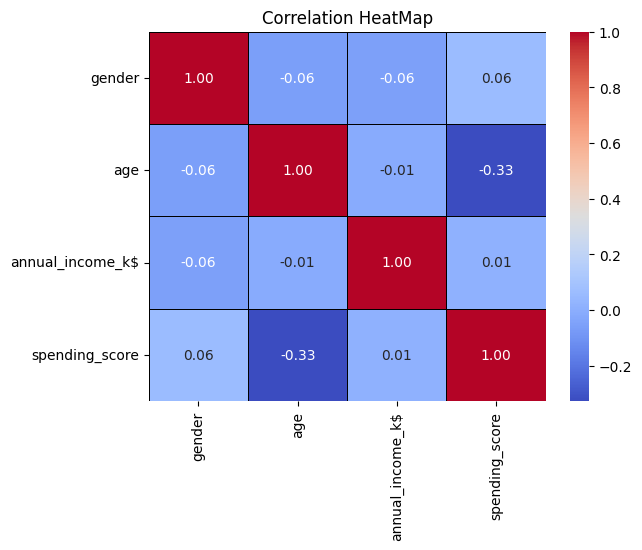

In [19]:
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm',linecolor='black',linewidths=0.5,fmt='.2f')
plt.title('Correlation HeatMap')

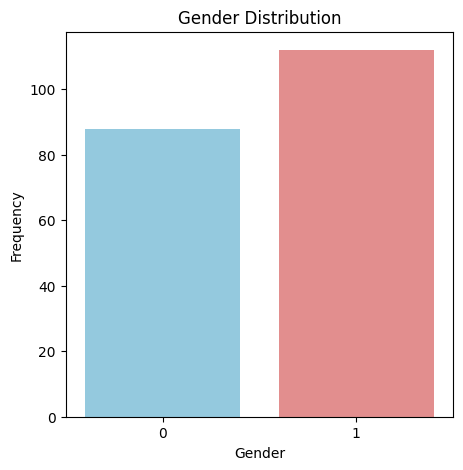

In [20]:
plt.figure(figsize=(5, 5))
sns.countplot(x="gender", data=df, palette=['skyblue', 'lightcoral'])
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.show()

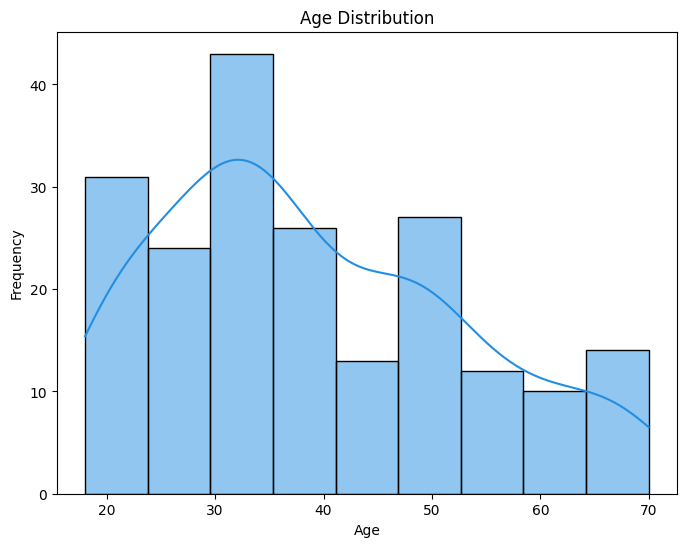

In [21]:
plt.figure(figsize=(8,6))
sns.histplot(df['age'], kde=True, color='#228EE3')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

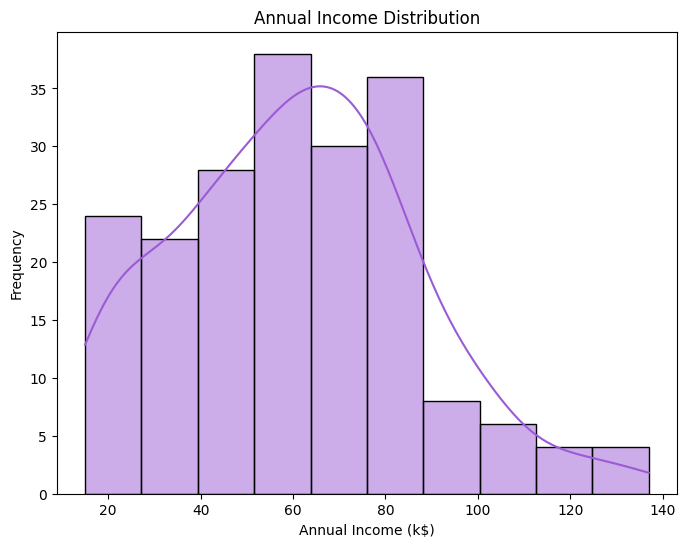

In [22]:
plt.figure(figsize=(8,6))
sns.histplot(df['annual_income_k$'], kde=True,color = '#9A5BD4')
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')
plt.show()

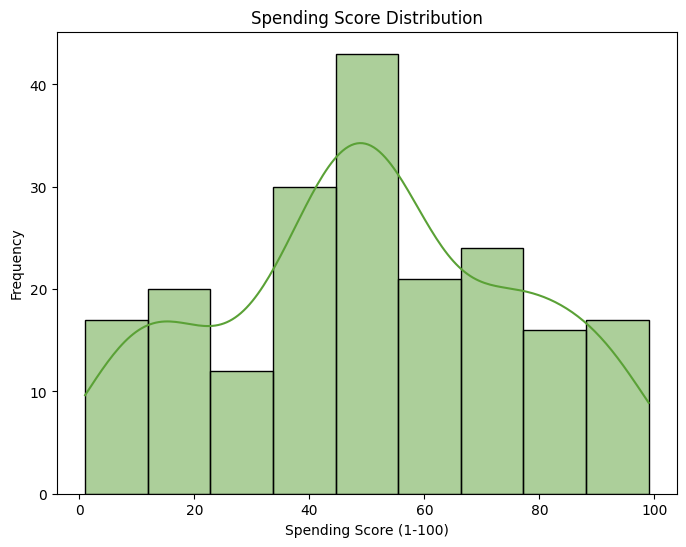

In [23]:
plt.figure(figsize=(8,6))
sns.histplot(df['spending_score'], kde=True,color = '#5AA136')
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Frequency')
plt.show()

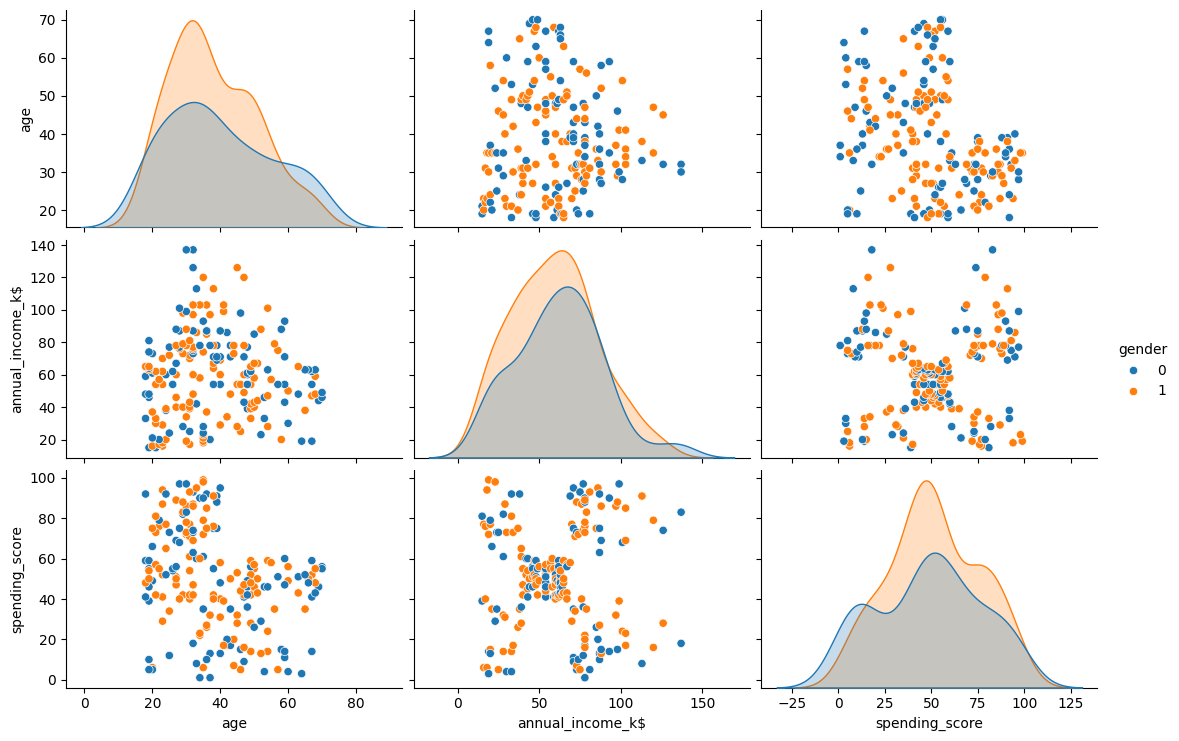

In [24]:
sns.pairplot(df, hue='gender', aspect=1.5)
plt.show()

- Lower Ages tend to show lower annual income and spending score
- The graph also shows that there may be some clustering in spending behavior across different income levels

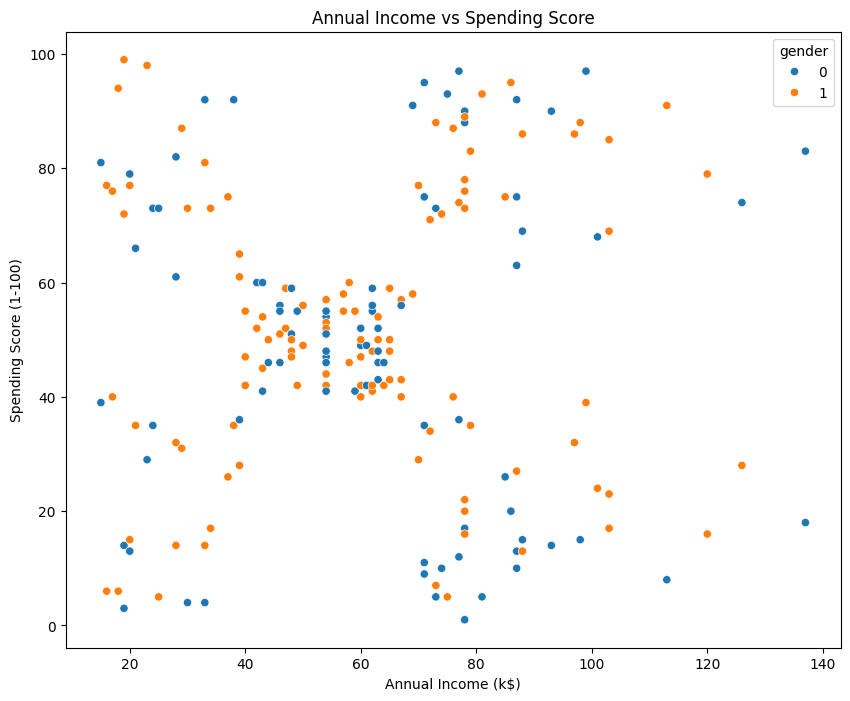

In [25]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df,x='annual_income_k$',y='spending_score',hue='gender')
plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [26]:
df[['annual_income_k$', 'spending_score']].head()

,annual_income_k$,spending_score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [27]:
df[['annual_income_k$', 'spending_score']].tail()

,annual_income_k$,spending_score
195,120,79
196,126,28
197,126,74
198,137,18
199,137,83


Annual Income vs Spending Score

In [28]:
sub1 = df[['annual_income_k$', 'spending_score']]
print(sub1.head())
scaler = StandardScaler()
scaler.fit(sub1)
StandardScaler(copy=True, with_mean=True, with_std=True)
samples_scaled = scaler.transform(sub1)

   annual_income_k$  spending_score
0                15              39
1                15              81
2                16               6
3                16              77
4                17              40


## K-Means Clustering Model

The Knee located at figure: 5


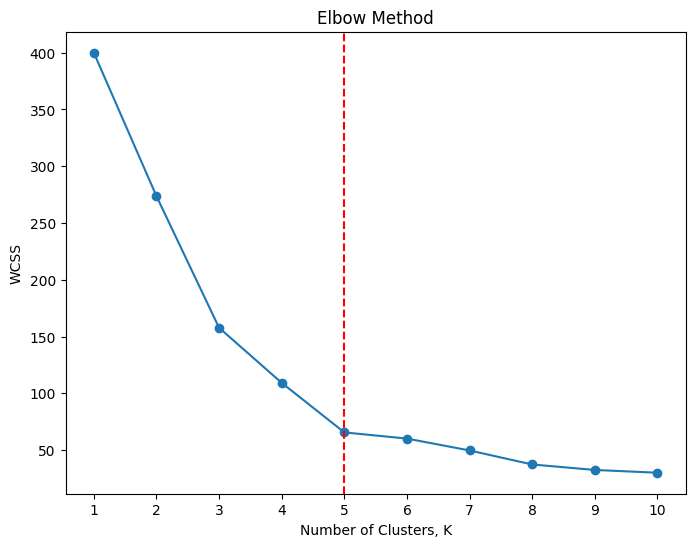

In [29]:
ks = range(1, 11)
wcss = []

for k in ks:
    model = KMeans(n_clusters=k, init='k-means++', random_state=42)
    model.fit(samples_scaled)
    wcss.append(model.inertia_)

kl = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
print('The Knee located at figure:', kl.elbow)

plt.figure(figsize=(8,6))
plt.plot(ks, wcss, '-o')
plt.xlabel('Number of Clusters, K')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.xticks(ks)
plt.axvline(x=kl.elbow, color='red', linestyle='--', label=f"Optimal K={kl.elbow}")
plt.show()


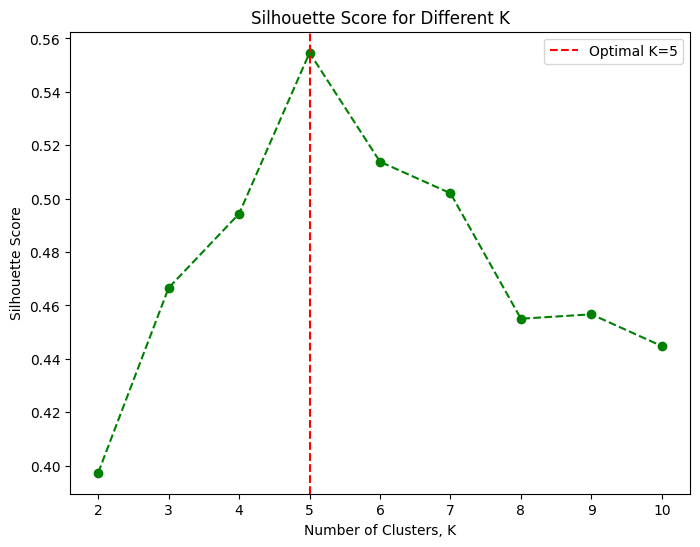

In [30]:
silhouette_coef = []
scf = range(2, 11)

for cluster in scf :
    kmeans = KMeans(n_clusters=cluster, init='k-means++', random_state=42)
    kmeans.fit(samples_scaled)
    score = silhouette_score(samples_scaled, kmeans.labels_)
    silhouette_coef.append(score)

plt.figure(figsize=(8, 6))
plt.plot(scf, silhouette_coef, 'o--', color='green')
plt.title('Silhouette Score for Different K')
plt.xlabel('Number of Clusters, K')
plt.ylabel('Silhouette Score')
plt.axvline(x=kl.elbow, color='red', linestyle='--', label=f"Optimal K={kl.elbow}")
plt.legend()
plt.show()


In [31]:
kmeans = KMeans(n_clusters=5,init='k-means++', random_state=42)
kmeans.fit(samples_scaled)
centers = kmeans.cluster_centers_
labels = kmeans.labels_

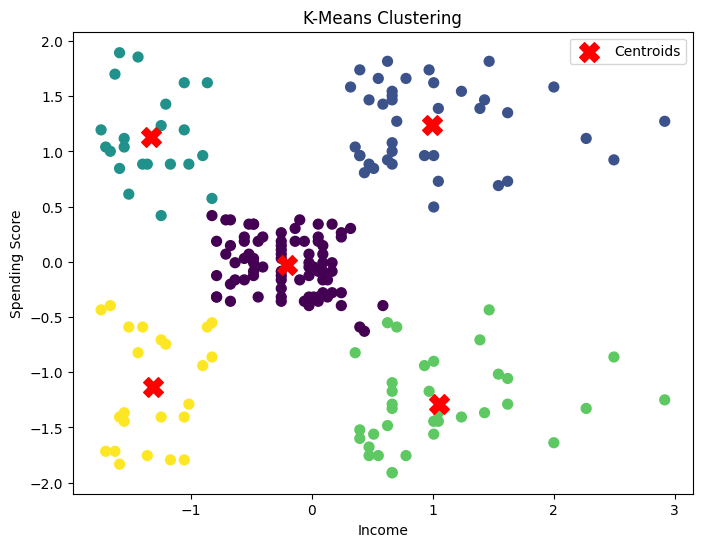

In [32]:
plt.figure(figsize=(8, 6))
plt.scatter(samples_scaled[:,0], samples_scaled[:,1], c = labels , cmap='viridis', s=50)
plt.scatter(centers[:, 0], centers[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.title('K-Means Clustering')
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

In [34]:
plt.figure(figsize=(10, 8))

df['KMeans_Cluster'] = labels

kmeans_cluster_data = df.groupby('KMeans_Cluster')[['annual_income_k$', 'spending_score']].mean().reset_index()

fig = px.bar(
    kmeans_cluster_data,
    x='KMeans_Cluster',
    y=['annual_income_k$', 'spending_score'],
    barmode='group',
    title="Annual Income and Spending Score by Cluster",
    labels={'value': 'Average Value', 'variable': 'Metrics'}
)

fig.update_layout(
    xaxis_title="Clusters",
    yaxis_title="Average Values",
    legend_title="Metrics",
    template='plotly_white',
    height = 500
)

fig.show()


<Figure size 1000x800 with 0 Axes>